In [ ]:
!pip install cvss

In [ ]:
import json
import requests
import zipfile
import io
import re
from datetime import datetime, timezone
from cvss import CVSS2, CVSS3, CVSS4

In [ ]:
allCWE = {}
CWEmetricks = {}

# Загрузка уязвимостей из каждой экосистемы (PyPI, npm, Go)

In [ ]:
ECOSYSTEMS = {
    "PyPI": "https://osv-vulnerabilities.storage.googleapis.com/PyPI/all.zip",
    "npm": "https://osv-vulnerabilities.storage.googleapis.com/npm/all.zip",  # в OSV экосистема называется npm
    "Go": "https://osv-vulnerabilities.storage.googleapis.com/Go/all.zip"
}

def download_and_extract_zip(url):
    """Скачивает ZIP-архив и возвращает список JSON-объектов (записей об уязвимостях)"""
    print(f"Загрузка {url}...")
    response = requests.get(url)
    if response.status_code != 200:
        print(f"Ошибка загрузки {url}: {response.status_code}")
        return []

    vulnerabilities = []
    # Открываем ZIP из загруженных байтов
    with zipfile.ZipFile(io.BytesIO(response.content)) as z:
        for filename in z.namelist():
            if filename.endswith('.json'):
                with z.open(filename) as f:
                    try:
                        vuln = json.load(f)
                        vulnerabilities.append(vuln)
                    except json.JSONDecodeError:
                        print(f"Ошибка чтения JSON из файла {filename}")
    return vulnerabilities

In [ ]:
pypi_vulnerabilities = download_and_extract_zip(ECOSYSTEMS['PyPI'])
npm_vulnerabilities = download_and_extract_zip(ECOSYSTEMS['npm'])
go_vulnerabilities = download_and_extract_zip(ECOSYSTEMS['Go'])

Загрузка https://osv-vulnerabilities.storage.googleapis.com/PyPI/all.zip...
Загрузка https://osv-vulnerabilities.storage.googleapis.com/npm/all.zip...


In [ ]:
for i in range(100):
  print(pypi_vulnerabilities[i]["database_specific"])

In [ ]:
ECOSYSTEM_archive = {"PyPI": pypi_vulnerabilities,"npm": npm_vulnerabilities, "Go" : go_vulnerabilities}

In [ ]:
for x in pypi_vulnerabilities:
  if "upstream" in x:
    if len(x["upstream"]) > 0:
      print(1)

In [ ]:
upstream_graph = {}   # Формат: { "ID": ["Upstream_ID_1", "Upstream_ID_2"] }
ecosystem_map = {}    # Формат: { "ID": "PyPI" } (чтобы знать, к кому относится)

In [ ]:
related_graph = {}

In [ ]:
relation = {}

In [ ]:
import json
import requests
import zipfile
import io
import re
import pandas as pd
import math
from datetime import datetime, timezone
from cvss import CVSS2, CVSS3, CVSS4

ECOSYSTEMS = {
    "PyPI": "https://osv-vulnerabilities.storage.googleapis.com/PyPI/all.zip",
    "npm": "https://osv-vulnerabilities.storage.googleapis.com/npm/all.zip",
    "Go": "https://osv-vulnerabilities.storage.googleapis.com/Go/all.zip"
}

def extract_cvss_severity(vuln):
    """Извлекает числовое значение из CVSS score"""
    severity_list = vuln.get("severity", [])
    for severity in severity_list:
        score_str = severity.get("score")
        match = re.search(r"(\d+\.?\d*)", score_str)
        if not match:
            continue
        if severity.get("type") == "CVSS_V4":
            c = CVSS4(severity.get("score"))
            return c.scores()[0]
        elif severity.get("type") == "CVSS_V3":
            c = CVSS3(severity.get("score"))
            return c.scores()[0]
        else:
            c = CVSS2(severity.get("score"))
            return c.scores()[0]
    return None

def calculate_fix_time_days(vuln):
    """Вычисляет время исправления в днях (разница между modified и published)"""
    published = vuln.get("published")
    modified = vuln.get("modified")

    if not published or not modified:
        return None
    try:
        pub_date = datetime.fromisoformat(published.replace('Z', '+00:00'))
        mod_date = datetime.fromisoformat(modified.replace('Z', '+00:00'))

        delta = mod_date - pub_date
        return delta.days
    except ValueError:
        return None

def process_ecosystem(ecosystem_name, url):
    """Основная функция для обработки одной экосистемы"""
    results = []

    ecosystem_cwe_count = {}
    ecosystem_cwe_metric = {}

    print(f"Скачивание архива для {ecosystem_name}...")
    response = requests.get(url)
    vulnerabilities = []
    with zipfile.ZipFile(io.BytesIO(response.content)) as z:
        for filename in z.namelist():
            if filename.endswith('.json'):
                with z.open(filename) as f:
                    vulnerabilities.append(json.load(f))

    total = len(vulnerabilities)
    print(f"Загружено {total} записей")

    # 2. Фильтруем и извлекаем данные
    for i, vuln in enumerate(vulnerabilities):
        if (i + 1) % 1000 == 0:
            print(f"Обработано {i+1}/{total} записей...")

        vuln_id = vuln.get("id")
        ecosystems = ecosystem_name
        ecosystem_map[vuln_id] = ecosystem_name

        upstreams = vuln.get("upstream", [])
        upstream_graph[vuln_id] = upstreams

        severity_score = extract_cvss_severity(vuln)
        if severity_score is None:
            continue
        fix_time = calculate_fix_time_days(vuln)
        if "database_specific" in vuln and "cwe_ids" in vuln["database_specific"]:
            for cwe in vuln["database_specific"]["cwe_ids"]:
                if cwe not in ecosystem_cwe_count:
                    ecosystem_cwe_count[cwe] = 0
                    ecosystem_cwe_metric[cwe] = 0

                ecosystem_cwe_count[cwe] += 1

                if fix_time is not None:
                  ecosystem_cwe_metric[cwe] += math.log(max(0, fix_time) + 1, 2) * pow(severity_score, 2)
        results.append({
            "id": vuln.get("id"),
            "ecosystem": ecosystem_name,
            "summary": vuln.get("summary", ""),
            "cvss_v3_score": severity_score,
            "fix_time_days": fix_time,
            "aliases": vuln.get("aliases", []),
            "related": vuln.get("related", {}),
            "published": vuln.get("published"),
            "modified": vuln.get("modified"),
            "cwe_ids": vuln.get("database_specific", {}).get("cwe_ids", [])
        })
    return results, ecosystem_cwe_count, ecosystem_cwe_metric

In [ ]:
if __name__ == "__main__":
    all_results = []
    system = {"PyPI" : [], "Go": [], "npm": []}

    all_counts_for_df = {}
    all_metrics_for_df = {}

    for name, url in ECOSYSTEMS.items():
        ecosystem_results, count_dict, metric_dict = process_ecosystem(name, url)
        for t in ecosystem_results:
          for ali in t['aliases']:
            relation[ali] = t['id']

        for t in ecosystem_results:
          p = t['related']
          res = []
          for x in p:
            if x in relation:
              res.append(relation[x])
            else:
              res.append(x)
          related_graph[t['id']] = res
        x = []
        y = []
        for j in range(100):
          x.append(ecosystem_results[j].get("fix_time_days"))
          y.append(ecosystem_results[j].get("cvss_v3_score"))
        system[name] = [x, y]


        all_results.extend(ecosystem_results)
        for cwe, count in count_dict.items():
          metric_dict[cwe] /= count
        all_counts_for_df[f"{name}_Count"] = count_dict
        all_metrics_for_df[f"{name}_Metric"] = metric_dict

    with open('vulnerabilities_analysis.json', 'w', encoding='utf-8') as f:
        json.dump(all_results, f, indent=2, ensure_ascii=False)
    df_counts = pd.DataFrame(all_counts_for_df)
    df_metrics = pd.DataFrame(all_metrics_for_df)
    df_final = pd.concat([df_counts, df_metrics], axis=1).fillna(0)
    columns_order = []
    for name in ECOSYSTEMS.keys():
        columns_order.extend([f"{name}_Count", f"{name}_Metric"])
    df_final = df_final[columns_order]

    df_final.to_csv("cwe_ecosystems_summary.csv")

In [ ]:
related_graph

# 100 точек из каждой экосистемы для отображения на графике : Зависимость severity и количетсва дней на устранение уязвимости

In [ ]:
print(f"PyPi X: {system["PyPI"][0]}")
print(f"Pypy Y: {system["PyPI"][1]}")

In [ ]:
print(f"Go X: {system["Go"][0]}")
print(f"GO Y: {system["Go"][1]}")

In [ ]:
print(f"Npm X: {system["npm"][0]}")
print(f"Npm Y: {system["npm"][1]}")

In [ ]:
df_pypi_sorted_by_count = df_final.sort_values(by="PyPI_Count", ascending=False)

In [ ]:
df_pypi_sorted_by_count

In [ ]:
df_npm_sorted_by_count = df_final.sort_values(by="npm_Count", ascending=False)

In [ ]:
df_go_sorted_by_count = df_final.sort_values(by="Go_Count", ascending=False)

In [ ]:
df_pypi_sorted_by_count.head(15)["PyPI_Count"].index

In [ ]:
all_cwes = df_npm_sorted_by_count["npm_Count"].index

In [ ]:
df_npm_sorted_by_count.head(15)["npm_Count"].values

In [ ]:
df_go_sorted_by_count.head(15)["Go_Count"].index

In [ ]:
df_go_sorted_by_count.head(15)["Go_Count"].values

# Определим для каждой CWE его текстовое определение

In [ ]:
import csv
import io
import requests

def load_cwe_dictionary():
    """Скачивает справочник CWE и возвращает словарь для маппинга"""
    print("Загрузка официального справочника CWE от MITRE...")
    # View 1000 - это самый полный список (Research Concepts)
    url = "https://cwe.mitre.org/data/csv/1000.csv.zip"

    response = requests.get(url)
    cwe_dict = {}

    with zipfile.ZipFile(io.BytesIO(response.content)) as z:
        # Внутри архива лежит файл 1000.csv
        with z.open('1000.csv') as f:
            # Читаем CSV
            csv_data = f.read().decode('utf-8')
            reader = csv.reader(io.StringIO(csv_data))

            headers = next(reader)
            # Индексы колонок в CSV: 0 - ID, 1 - Name, 2 - Abstraction (уровень)
            for row in reader:
                if len(row) > 2:
                    cwe_id = f"CWE-{row[0]}"
                    cwe_name = row[1]
                    cwe_dict[cwe_id] = cwe_name

    print(f"Загружено {len(cwe_dict)} описаний CWE.")
    return cwe_dict

In [ ]:
cwe_dict = load_cwe_dictionary()

In [ ]:
cwe_dict

{'CWE-5': 'J2EE Misconfiguration: Data Transmission Without Encryption',
 'CWE-6': 'J2EE Misconfiguration: Insufficient Session-ID Length',
 'CWE-7': 'J2EE Misconfiguration: Missing Custom Error Page',
 'CWE-8': 'J2EE Misconfiguration: Entity Bean Declared Remote',
 'CWE-9': 'J2EE Misconfiguration: Weak Access Permissions for EJB Methods',
 'CWE-11': 'ASP.NET Misconfiguration: Creating Debug Binary',
 'CWE-12': 'ASP.NET Misconfiguration: Missing Custom Error Page',
 'CWE-13': 'ASP.NET Misconfiguration: Password in Configuration File',
 'CWE-14': 'Compiler Removal of Code to Clear Buffers',
 'CWE-15': 'External Control of System or Configuration Setting',
 'CWE-20': 'Improper Input Validation',
 'CWE-22': "Improper Limitation of a Pathname to a Restricted Directory ('Path Traversal')",
 'CWE-23': 'Relative Path Traversal',
 'CWE-24': "Path Traversal: '../filedir'",
 'CWE-25': "Path Traversal: '/../filedir'",
 'CWE-26': "Path Traversal: '/dir/../filename'",
 'CWE-27': "Path Traversal: 'd

In [ ]:
most_py_cwes = df_pypi_sorted_by_count.head(15)["PyPI_Count"].index

In [ ]:
most_py_cwes

Index(['CWE-79', 'CWE-22', 'CWE-20', 'CWE-200', 'CWE-400', 'CWE-502', 'CWE-94',
       'CWE-918', 'CWE-770', 'CWE-125', 'CWE-787', 'CWE-863', 'CWE-89',
       'CWE-601', 'CWE-78'],
      dtype='object')

In [ ]:
most_npm_cwes = df_npm_sorted_by_count.head(15)["npm_Count"].index

In [ ]:
most_go_cwes = df_go_sorted_by_count.head(15)["Go_Count"].index

# Работа с графами, насколько длинная может зависимость из уязвимостей?

In [ ]:
if __name__ == "__main__":
    for name in ECOSYSTEMS.keys():
        metric_col = f"{name}_Metric"

        # Проверяем, что колонка существует (на случай, если экосистема была пустой)
        if metric_col in df_final.columns:
            # Получаем 10 самых больших значений из колонки метрики
            top_10 = df_final[metric_col].nlargest(20)

            print(f"\n🚀 Экосистема: {name}")
            print("-" * 35)

            # Выводим с нумерацией
            for rank, (cwe, score) in enumerate(top_10.items(), start=1):
                # Если метрика равна 0, значит значимых уязвимостей больше нет
                if score == 0:
                    break

                # Достаем количество (Count) для полноты картины
                count_col = f"{name}_Count"
                cwe_count = int(df_final.at[cwe, count_col])

                # Форматированный вывод (выравнивание пробелами для красоты)
                print(f"{rank:2d}. {cwe:<10} | Метрика: {score:10,.2f} | С какой областью связана уязвимость: {cwe_dict[cwe]} | Кол-во: {cwe_count}")

    print("\n" + "="*50)


🚀 Экосистема: PyPI
-----------------------------------
 1. CWE-242    | Метрика:   1,058.45 | С какой областью связана уязвимость: Use of Inherently Dangerous Function | Кол-во: 1
 2. CWE-1056   | Метрика:   1,025.40 | С какой областью связана уязвимость: Invokable Control Element with Variadic Parameters | Кол-во: 1
 3. CWE-270    | Метрика:     897.00 | С какой областью связана уязвимость: Privilege Context Switching Error | Кол-во: 1
 4. CWE-197    | Метрика:     887.99 | С какой областью связана уязвимость: Numeric Truncation Error | Кол-во: 1
 5. CWE-31     | Метрика:     825.45 | С какой областью связана уязвимость: Path Traversal: 'dir....filename' | Кол-во: 1
 6. CWE-641    | Метрика:     824.54 | С какой областью связана уязвимость: Improper Restriction of Names for Files and Other Resources | Кол-во: 1
 7. CWE-96     | Метрика:     823.70 | С какой областью связана уязвимость: Improper Neutralization of Directives in Statically Saved Code ('Static Code Injection') | Кол-во: 

In [ ]:
def find_longest_upstream_chains(graph):
    print("\n--- Анализ графа Upstream ---")
    memo = {}        # Кэш длин: { "ID": длина }
    path_memo = {}   # Кэш самих путей: { "ID": ["ID1", "ID2", ...] }

    def dfs(node):
        # Если уже считали этот узел, просто возвращаем результат
        if node in memo:
            return memo[node], path_memo[node]

        if node not in graph or not graph[node]:
            return 1, [node]

        max_len = 0
        best_path = []

        # Проверяем все ветки related и ищем самую длинную
        for neighbor in graph[node]:
            if neighbor == node or neighbor:
              continue
            length, path = dfs(neighbor)
            if length > max_len:
                max_len = length
                best_path = path

        # Сохраняем результат: свой узел + лучший путь из соседей
        memo[node] = max_len + 1
        path_memo[node] = [node] + best_path

        return memo[node], path_memo[node]

    # 1. Считаем длины для всех узлов
    for node in graph.keys():
        dfs(node)
    return memo, path_memo

In [ ]:
ans = find_longest_upstream_chains(related_graph)


--- Анализ графа Upstream ---


In [ ]:
for key in related_graph.keys():
  if "GHSA" not in key:
    print(key)

PYSEC-2016-38
PYSEC-2016-39
PYSEC-2016-40
PYSEC-2016-41
PYSEC-2017-105
PYSEC-2017-106
PYSEC-2017-107
PYSEC-2017-108
PYSEC-2017-109
PYSEC-2017-110
PYSEC-2017-111
PYSEC-2017-112
PYSEC-2017-113
PYSEC-2017-114
PYSEC-2017-115
PYSEC-2017-116
PYSEC-2017-117
PYSEC-2017-118
PYSEC-2017-119
PYSEC-2017-120
PYSEC-2017-121
PYSEC-2017-122
PYSEC-2017-123
PYSEC-2017-124
PYSEC-2017-125
PYSEC-2017-126
PYSEC-2017-127
PYSEC-2017-128
PYSEC-2017-129
PYSEC-2017-130
PYSEC-2017-131
PYSEC-2017-132
PYSEC-2017-133
PYSEC-2017-134
PYSEC-2017-135
PYSEC-2017-136
PYSEC-2017-137
PYSEC-2017-138
PYSEC-2017-139
PYSEC-2017-140
PYSEC-2017-141
PYSEC-2017-142
PYSEC-2017-143
PYSEC-2017-144
PYSEC-2017-145
PYSEC-2017-146
PYSEC-2017-147
PYSEC-2017-148
PYSEC-2017-149
PYSEC-2017-150
PYSEC-2017-151
PYSEC-2018-117
PYSEC-2018-118
PYSEC-2018-119
PYSEC-2018-120
PYSEC-2018-121
PYSEC-2018-122
PYSEC-2018-123
PYSEC-2018-124
PYSEC-2018-125
PYSEC-2018-126
PYSEC-2018-127
PYSEC-2018-128
PYSEC-2018-129
PYSEC-2018-130
PYSEC-2018-131
PYSEC-2018-132

#🔝 Кажется в экосистемах мало upstream данных

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

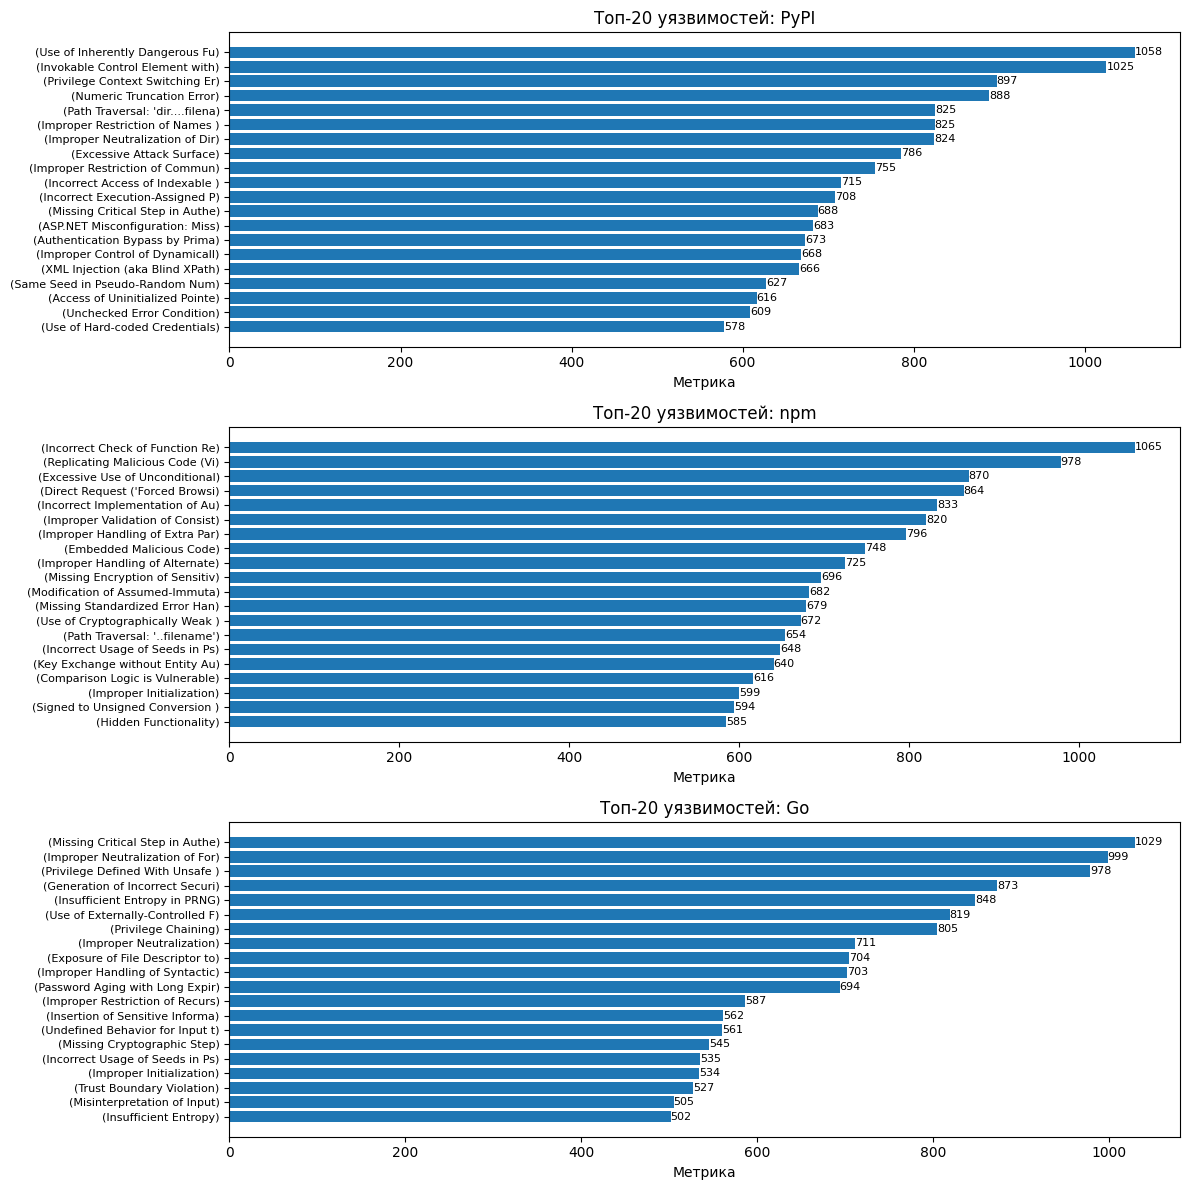

In [108]:
import matplotlib.pyplot as plt
import numpy as np

if __name__ == "__main__":
    fig, axes = plt.subplots(len(ECOSYSTEMS), 1, figsize=(12, 4*len(ECOSYSTEMS)))

    if len(ECOSYSTEMS) == 1:
        axes = [axes]

    for idx, (name, ax) in enumerate(zip(ECOSYSTEMS.keys(), axes)):
        metric_col = f"{name}_Metric"

        if metric_col in df_final.columns:
            top_20 = df_final[metric_col].nlargest(20)
            # Убираем нулевые значения
            top_20 = top_20[top_20 > 0]

            if len(top_20) == 0:
                ax.text(0.5, 0.5, f'Нет данных для {name}',
                       ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f'Экосистема: {name}')
                continue

            # Создаем более читаемые метки
            labels = [f"({cwe_dict.get(cwe, 'Unknown')[:30]})"
                     for cwe in top_20.index]

            # Горизонтальная столбчатая диаграмма
            bars = ax.barh(range(len(top_20)), top_20.values)
            ax.set_yticks(range(len(top_20)))
            ax.set_yticklabels(labels, fontsize=8)
            ax.set_xlabel('Метрика')
            ax.set_title(f'Топ-20 уязвимостей: {name}')
            ax.invert_yaxis()  # Самые большие сверху

            # Добавляем значения на столбцы
            for i, (bar, val) in enumerate(zip(bars, top_20.values)):
                ax.text(val, bar.get_y() + bar.get_height()/2,
                       f'{val:.0f}', ha='left', va='center', fontsize=8)

    plt.tight_layout()
    plt.show()

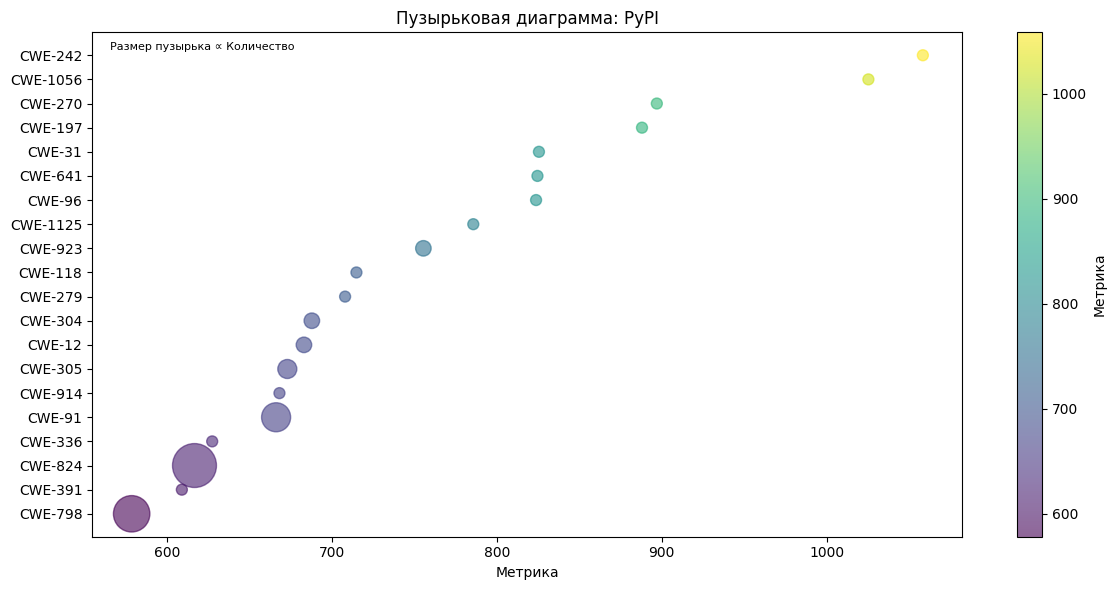

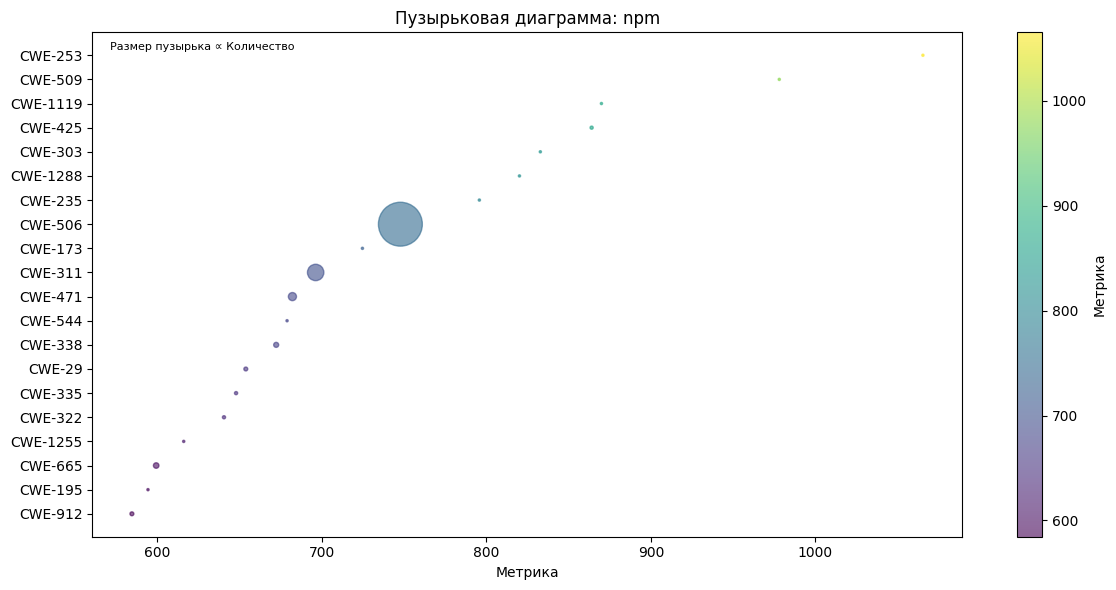

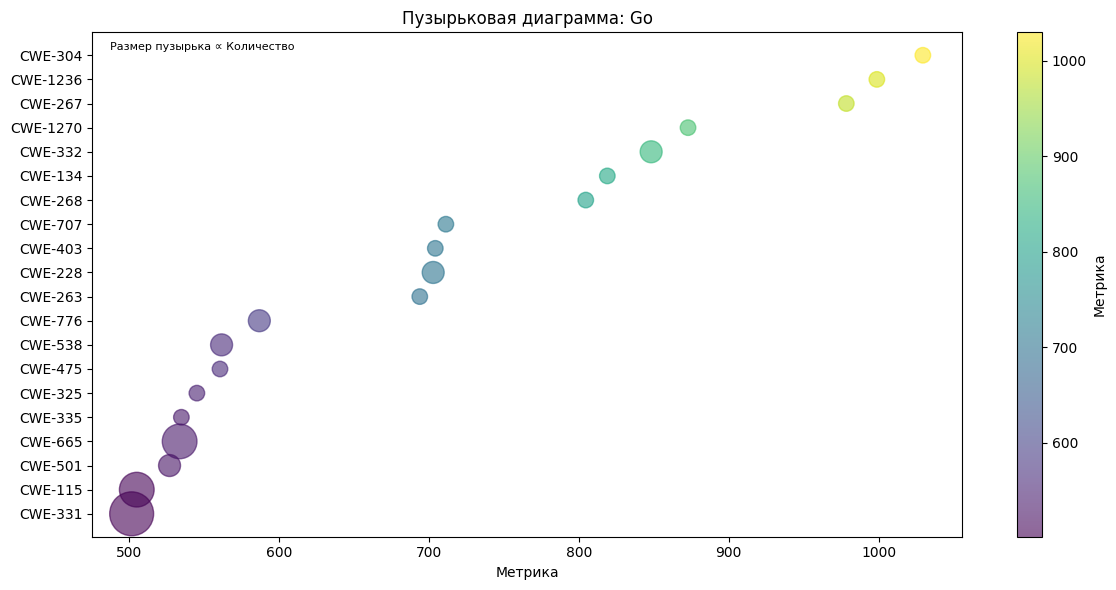

In [109]:
if __name__ == "__main__":
    for name in ECOSYSTEMS.keys():
        metric_col = f"{name}_Metric"
        count_col = f"{name}_Count"

        if metric_col in df_final.columns and count_col in df_final.columns:
            top_20 = df_final[metric_col].nlargest(20)
            top_20 = top_20[top_20 > 0]

            if len(top_20) > 0:
                plt.figure(figsize=(12, 6))

                # Размер пузырьков на основе Count
                sizes = [df_final.at[cwe, count_col] for cwe in top_20.index]
                # Нормализуем размеры для лучшей видимости
                sizes = [s/max(sizes)*1000 for s in sizes]

                scatter = plt.scatter(top_20.values, range(len(top_20)),
                                    s=sizes, alpha=0.6, c=top_20.values,
                                    cmap='viridis')

                plt.yticks(range(len(top_20)), top_20.index)
                plt.xlabel('Метрика')
                plt.title(f'Пузырьковая диаграмма: {name}')
                plt.colorbar(scatter, label='Метрика')
                plt.gca().invert_yaxis()

                # Добавляем легенду для размера пузырьков
                plt.text(0.02, 0.98, 'Размер пузырька ∝ Количество',
                        transform=plt.gca().transAxes, fontsize=8,
                        verticalalignment='top')

                plt.tight_layout()
                plt.show()

# Сгрупируем относитльно CWE-699 (for programming enginers) CWE внутри наших данных

In [ ]:
most_py_cwes

Index(['CWE-79', 'CWE-22', 'CWE-20', 'CWE-200', 'CWE-400', 'CWE-502', 'CWE-94',
       'CWE-918', 'CWE-770', 'CWE-125', 'CWE-787', 'CWE-863', 'CWE-89',
       'CWE-601', 'CWE-78'],
      dtype='object')

In [105]:
import xml.etree.ElementTree as ET

def get_highest_parents_for_view(xml_path, target_view="1000"):
    # Пространство имен, используемое в XML документации CWE
    ns = {'cwe': 'http://cwe.mitre.org/cwe-7'}

    tree = ET.parse(xml_path)
    root = tree.getroot()

    parents_map = {}

    for weakness in root.findall('.//cwe:Weaknesses/cwe:Weakness', ns):
        w_id = weakness.attrib.get('ID')
        for related in weakness.findall('.//cwe:Related_Weaknesses/cwe:Related_Weakness', ns):
            if related.attrib.get('View_ID') == target_view and related.attrib.get('Nature') == 'ChildOf':
                parent_id = related.attrib.get('CWE_ID')
                parents_map.setdefault(w_id, set()).add(parent_id)
    containers = root.findall('.//cwe:Categories/cwe:Category', ns) + root.findall('.//cwe:Views/cwe:View', ns)
    for container in containers:
        parent_id = container.attrib.get('ID')
        for member in container.findall('.//cwe:Relationships/cwe:Has_Member', ns):
            if member.attrib.get('View_ID') == target_view:
                child_id = member.attrib.get('CWE_ID')
                parents_map.setdefault(child_id, set()).add(parent_id)

    def find_roots(node_id, visited=None):
        if visited is None:
            visited = set()

        # Защита от зацикливания (на случай циклических связей)
        if node_id in visited:
            return set()
        visited.add(node_id)

        if node_id not in parents_map or not parents_map[node_id]:
            return {node_id}

        roots = set()
        for parent_id in parents_map[node_id]:
            roots.update(find_roots(parent_id, visited.copy()))
        return roots

    highest_parents = {}
    for child_id in parents_map.keys():
        highest_parents[child_id] = find_roots(child_id)

    return highest_parents

In [106]:
file_path = "cwec_v4.20.xml"
results = get_highest_parents_for_view(file_path, target_view="1000")
cwe_1000_roots = ['284', '435', '664', '682', '691', '693', '697', '703', '707', '710']

t = most_py_cwes

cluster = {}

for cwe in all_cwes:
  roots = results.get(cwe[4:], "Связи в View 1000 не найдены")

  cluster[cwe] = roots

In [95]:
cluster

{'CWE-79': {'137'},
 'CWE-1321': 'Связи в View 699 не найдены',
 'CWE-22': {'1219'},
 'CWE-506': 'Связи в View 699 не найдены',
 'CWE-400': 'Связи в View 699 не найдены',
 'CWE-78': {'137'},
 'CWE-94': {'137'},
 'CWE-20': 'Связи в View 699 не найдены',
 'CWE-863': 'Связи в View 699 не найдены',
 'CWE-918': {'417'},
 'CWE-200': 'Связи в View 699 не найдены',
 'CWE-77': 'Связи в View 699 не найдены',
 'CWE-1333': {'1226'},
 'CWE-74': 'Связи в View 699 не найдены',
 'CWE-770': {'399', '840'},
 'CWE-287': 'Связи в View 699 не найдены',
 'CWE-915': {'399'},
 'CWE-284': 'Связи в View 699 не найдены',
 'CWE-601': {'19'},
 'CWE-89': {'137'},
 'CWE-862': 'Связи в View 699 не найдены',
 'CWE-639': {'1212', '840'},
 'CWE-352': 'Связи в View 699 не найдены',
 'CWE-347': {'1214', '310'},
 'CWE-285': 'Связи в View 699 не найдены',
 'CWE-311': 'Связи в View 699 не найдены',
 'CWE-269': 'Связи в View 699 не найдены',
 'CWE-306': {'1211'},
 'CWE-59': {'1219'},
 'CWE-367': {'557'},
 'CWE-345': 'Связи в 

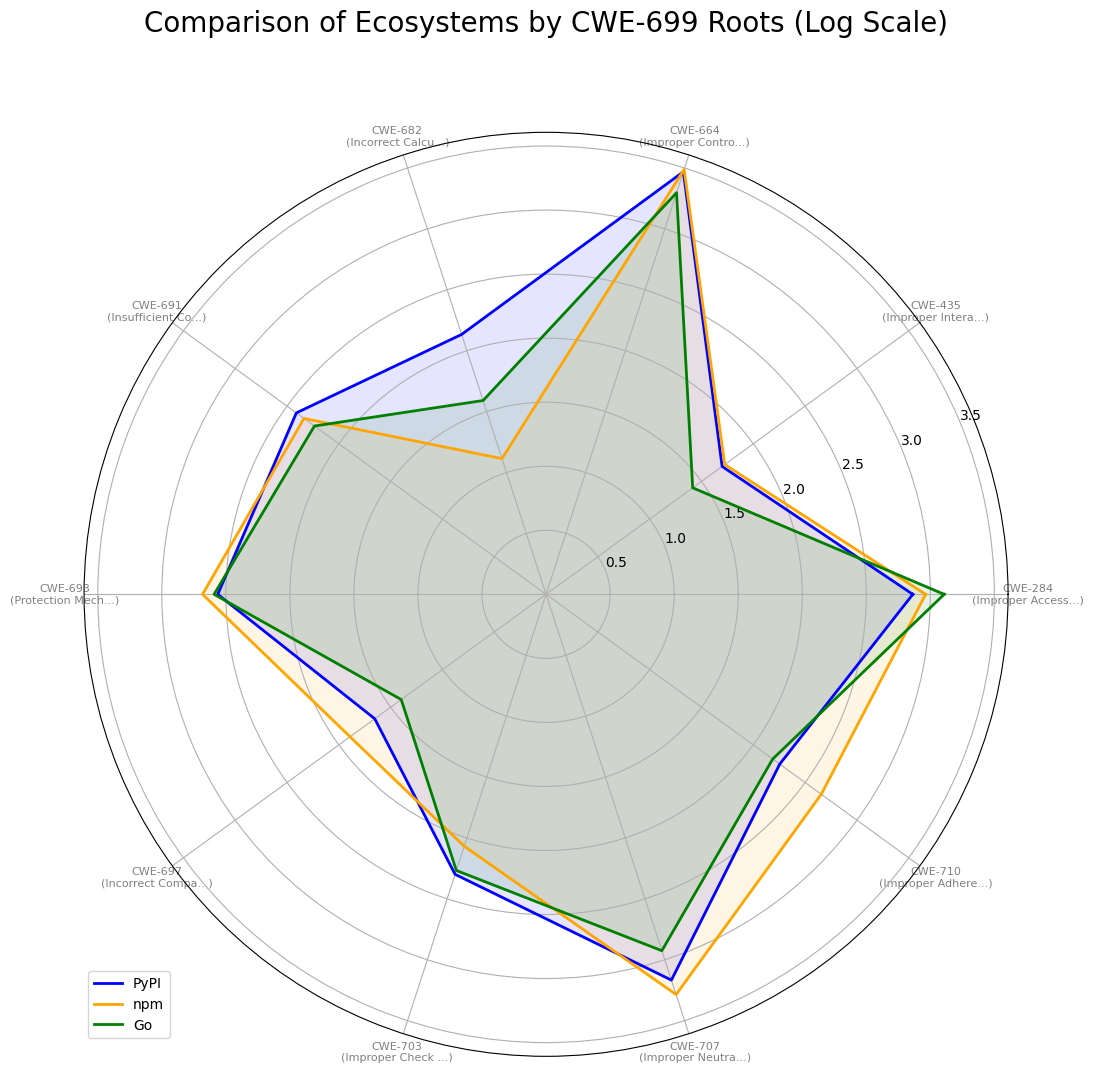

In [107]:
import numpy as np
import matplotlib.pyplot as plt

ecosystems = ['PyPI', 'npm', 'Go']
radar_data = {root: {eco: 0 for eco in ecosystems} for root in cwe_1000_roots}

for cwe_id in df_final.index:
    roots = cluster.get(cwe_id, set())
    if isinstance(roots, set):
        for root in roots:
            if root in radar_data:
                for eco in ecosystems:
                    radar_data[root][eco] += df_final.at[cwe_id, f"{eco}_Count"]

categories = cwe_1000_roots
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(polar=True))

labels = [f"CWE-{r}\n({cwe_dict.get('CWE-'+r, 'Unknown')[:15]}...)" for r in categories]
plt.xticks(angles[:-1], labels, color='grey', size=8)

colors = {'PyPI': 'blue', 'npm': 'orange', 'Go': 'green'}
for eco in ecosystems:
    values = [radar_data[root][eco] for root in categories]
    log_values = [np.log10(v + 1) for v in values]
    log_values += log_values[:1]

    ax.plot(angles, log_values, linewidth=2, linestyle='solid', label=eco, color=colors[eco])
    ax.fill(angles, log_values, color=colors[eco], alpha=0.1)

plt.title("Comparison of Ecosystems by CWE-699 Roots (Log Scale)", size=20, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.show()

# Новый раздел